# Data Cleaning: NYC Airbnb Listings

**Goal:** Demonstrate a complete, professional data-cleaning workflow on a
messy NYC Airbnb-style dataset, covering the five core concepts:

1. Data Integrity — load and inspect the raw data
2. Missing Data Handling
3. Duplicate Removal
4. Standardization
5. Outlier Detection

**Dataset:** `nyc_airbnb_data.csv` — listing-level data with columns: `id`,
`name`, `host_id`, `host_name`, `neighbourhood_group`, `neighbourhood`,
`latitude`, `longitude`, `room_type`, `price`, `minimum_nights`,
`number_of_reviews`, `last_review`, `reviews_per_month`,
`calculated_host_listings_count`, `availability_365`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

## 1. Data Integrity — Initial Inspection

Before cleaning anything, we need a clear picture of the raw data: its shape,
column types, value ranges, and obvious red flags.

In [2]:
df = pd.read_csv("data/nyc_airbnb_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (6070, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1000000,Spacious entire home near Chelsea subway,18635,Wei G.,Manhattan,Chelsea,40.76759,-73.98548,Entire home/apt,139,1,9,2023-08-20,0.34,4,33
1,1000001,Cozy shared room in Chelsea,31488,Patricia C.,Manhattan,Chelsea,40.76816,-73.95948,Shared room,23,1,7,2022-10-15,0.33,1,123
2,1000002,Cozy entire home in Bedford-Stuyvesant,21885,Jennifer F.,Brooklyn,Bedford-Stuyvesant,40.69268,-73.92529,Entire home/apt,327,5,0,NaN,NaN,1,45
3,1000003,Upper West Side private room with great views,38729,Robert G.,Manhattan,Upper West Side,40.79211,-73.99189,Private room,132,2,6,2024-11-21,0.51,4,173
4,1000004,Sunny shared room close to everything - East Village,36657,William H.,Manhattan,East Village,40.77733,-73.95488,Shared room,24,1,11,2023-02-12,1.15,2,211


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6070 entries, 0 to 6069
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              6070 non-null   int64  
 1   name                            6029 non-null   str    
 2   host_id                         6070 non-null   int64  
 3   host_name                       6030 non-null   str    
 4   neighbourhood_group             6019 non-null   str    
 5   neighbourhood                   6070 non-null   str    
 6   latitude                        6070 non-null   float64
 7   longitude                       6070 non-null   float64
 8   room_type                       6070 non-null   str    
 9   price                           6070 non-null   int64  
 10  minimum_nights                  6070 non-null   int64  
 11  number_of_reviews               6070 non-null   int64  
 12  last_review                     5581 non-null

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,6070.0,NaN,NaN,NaN,1003000.702471,1733.582363,1000000.0,1001501.25,1003002.5,1004503.75,1005999.0
name,6029,394,Modern entire home - Upper West Side,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,6070.0,NaN,NaN,NaN,35020.294893,14592.022249,10004.0,22305.5,34918.0,47516.0,59989.0
host_name,6030,160,David C.,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,6019,10,Manhattan,2366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,6070,44,Hell's Kitchen,421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,6070.0,NaN,NaN,NaN,40.677929,1.479254,0.0,40.68192,40.736135,40.78283,40.8997
longitude,6070.0,NaN,NaN,NaN,-73.839034,2.683794,-74.19842,-73.97308,-73.951515,-73.919668,0.0
room_type,6070,6,Entire home/apt,3087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,6070.0,NaN,NaN,NaN,187.011367,414.930518,0.0,90.0,134.0,254.75,16967.0


In [5]:
# Quick integrity checks
print("Unique listing IDs vs total rows:", df['id'].nunique(), "/", len(df))
print("Negative or zero prices:", (df['price'] <= 0).sum())
print("Extreme minimum_nights (> 365):", (df['minimum_nights'] > 365).sum())
print("Latitude/Longitude == 0:", ((df['latitude'] == 0) & (df['longitude'] == 0)).sum())
print("Unique neighbourhood_group values:", df['neighbourhood_group'].unique())
print("Unique room_type values:", df['room_type'].unique())

Unique listing IDs vs total rows: 6000 / 6070
Negative or zero prices: 25
Extreme minimum_nights (> 365): 10
Latitude/Longitude == 0: 8
Unique neighbourhood_group values: <StringArray>
[    'Manhattan',      'Brooklyn',        'Queens', 'Staten Island',
         'Bronx',      'BROOKLYN',     'MANHATTAN',             nan,
        'QUEENS', 'STATEN ISLAND',         'BRONX']
Length: 11, dtype: str
Unique room_type values: <StringArray>
['Entire home/apt',     'Shared room',    'Private room',    'private room',
 'entire home/apt',     'shared room']
Length: 6, dtype: str


**Findings:**
- `id` is not unique across all rows — there are duplicate listing IDs, which
  likely correspond to duplicate rows.
- Some listings have `price == 0`, which is invalid for a real booking.
- A handful of listings have unrealistically high `minimum_nights`.
- Some rows have `latitude`/`longitude` both equal to 0 — a classic
  placeholder for missing geocoding.
- `neighbourhood_group` and `room_type` have inconsistent text casing
  (e.g., `"MANHATTAN"` vs `"Manhattan"`, `"private room"` vs `"Private room"`).

We'll address each of these systematically below.

## 2. Missing Data Handling

In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_pct
reviews_per_month,489,8.06
last_review,489,8.06
neighbourhood_group,51,0.84
name,41,0.68
host_name,40,0.66


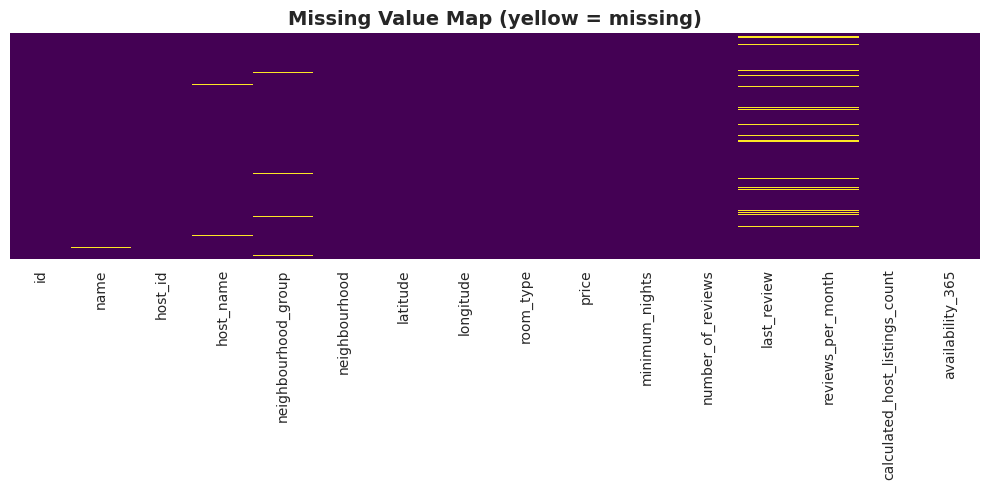

In [7]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Value Map (yellow = missing)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/missing_value_map.png", dpi=120)
plt.show()

**Strategy for each column:**

- `name` (40 missing): Free-text listing title, not used in numeric analysis.
  Fill with a placeholder `"No title"` so the column remains usable for
  text-based features without dropping rows.
- `host_name` (40 missing): Same — fill with `"Unknown"`.
- `neighbourhood_group` (51 missing): This is a key categorical feature.
  Rather than guessing, fill with `"Unknown"` so these rows remain usable for
  most analyses but are clearly flagged.
- `last_review` / `reviews_per_month` (489 missing each): These are missing
  **because the listing has zero reviews** — this is informative missingness,
  not random. We confirm this relationship, then fill `reviews_per_month`
  with 0 and leave `last_review` as missing (representing "never reviewed").

In [8]:
# Confirm that missing last_review / reviews_per_month corresponds to 0 reviews
no_review_mask = df["number_of_reviews"] == 0
print("Rows with 0 reviews:", no_review_mask.sum())
print("Rows with missing last_review:", df["last_review"].isna().sum())
print("Rows with 0 reviews AND missing last_review:",
      (no_review_mask & df["last_review"].isna()).sum())

Rows with 0 reviews: 489
Rows with missing last_review: 489
Rows with 0 reviews AND missing last_review: 489


In [9]:
# Apply missing-value strategy
df["name"] = df["name"].fillna("No title")
df["host_name"] = df["host_name"].fillna("Unknown")
df["neighbourhood_group"] = df["neighbourhood_group"].fillna("Unknown")
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
# last_review stays as NaN -> meaning "never reviewed"; convert to datetime
df["last_review"] = pd.to_datetime(df["last_review"])

df.isna().sum()

id                                  0
name                                0
host_id                             0
host_name                           0
neighbourhood_group                 0
neighbourhood                       0
latitude                            0
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                       489
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
dtype: int64

## 3. Duplicate Removal

In [10]:
# Exact duplicate rows
exact_dupes = df.duplicated().sum()
print("Exact duplicate rows:", exact_dupes)

# Duplicate listing IDs (should be unique - a listing should appear once)
id_dupes = df["id"].duplicated().sum()
print("Duplicate 'id' values:", id_dupes)

Exact duplicate rows: 65
Duplicate 'id' values: 70


In [11]:
# Inspect a sample of duplicated IDs
dup_ids = df[df["id"].duplicated(keep=False)].sort_values("id")
dup_ids.head(6)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
24,1000024,Kingsbridge entire home with great views,33812,John H.,Bronx,Kingsbridge,40.86055,-73.86994,Entire home/apt,375,1,5,2024-11-03,0.58,1,128
6069,1000024,Kingsbridge entire home with great views,33812,John H.,Bronx,Kingsbridge,40.86055,-73.86994,Entire home/apt,375,1,5,2024-11-03,0.58,1,128
6041,1000030,Modern entire home - Upper West Side,10920,John E.,Manhattan,Upper West Side,40.80946,-73.96287,Entire home/apt,288,7,10,2022-09-13,0.37,1,21
30,1000030,Modern entire home - Upper West Side,10920,John E.,Manhattan,Upper West Side,40.80946,-73.96287,Entire home/apt,288,7,10,2022-09-13,0.37,1,21
6064,1000047,Ridgewood entire home with great views,14364,Robert C.,Queens,Ridgewood,40.75510,-73.78270,Entire home/apt,218,3,10,2023-12-04,0.57,1,8
47,1000047,Ridgewood entire home with great views,14364,Robert C.,Queens,Ridgewood,40.75510,-73.78270,Entire home/apt,218,3,10,2023-12-04,0.57,1,8


In [12]:
before = len(df)
df = df.drop_duplicates(subset="id", keep="first").reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate listing rows")
print("New shape:", df.shape)
print("Remaining duplicate ids:", df['id'].duplicated().sum())

Removed 70 duplicate listing rows
New shape: (6000, 16)
Remaining duplicate ids: 0


## 4. Standardization

In [13]:
print("neighbourhood_group values before:", sorted(df['neighbourhood_group'].unique()))
print("room_type values before:", sorted(df['room_type'].unique()))
print("Sample neighbourhood values with whitespace:",
      [n for n in df['neighbourhood'].unique() if n != n.strip()][:5])

neighbourhood_group values before: ['BRONX', 'BROOKLYN', 'Bronx', 'Brooklyn', 'MANHATTAN', 'Manhattan', 'QUEENS', 'Queens', 'STATEN ISLAND', 'Staten Island', 'Unknown']
room_type values before: ['Entire home/apt', 'Private room', 'Shared room', 'entire home/apt', 'private room', 'shared room']
Sample neighbourhood values with whitespace: ["  Hell's Kitchen  ", '  Tompkinsville  ', '  Ridgewood  ', '  Harlem  ', '  Bushwick  ']


**Standardization steps:**
- Normalize casing for `neighbourhood_group` and `room_type` to Title Case
  so that e.g. `"MANHATTAN"`, `"manhattan"`, and `"Manhattan"` are all treated
  as the same category.
- Strip leading/trailing whitespace from `neighbourhood`.
- Ensure numeric columns (`price`, `minimum_nights`, `availability_365`,
  `calculated_host_listings_count`) are proper integer/float types.
- Recompute `"Unknown"` for `neighbourhood_group` after title-casing, since
  `.title()` would otherwise turn it into `"Unknown"` consistently anyway —
  but we verify this explicitly.

In [14]:
# Standardize text columns
df["neighbourhood_group"] = df["neighbourhood_group"].str.strip().str.title()
df["room_type"] = df["room_type"].str.strip().str.title()
df["neighbourhood"] = df["neighbourhood"].str.strip()

print("neighbourhood_group values after:", sorted(df['neighbourhood_group'].unique()))
print("room_type values after:", sorted(df['room_type'].unique()))

neighbourhood_group values after: ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Unknown']
room_type values after: ['Entire Home/Apt', 'Private Room', 'Shared Room']


In [15]:
# Ensure correct dtypes for numeric columns
numeric_cols = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month",
                 "calculated_host_listings_count", "availability_365", "latitude", "longitude"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols].dtypes

price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
latitude                          float64
longitude                         float64
dtype: object

## 5. Outlier Detection

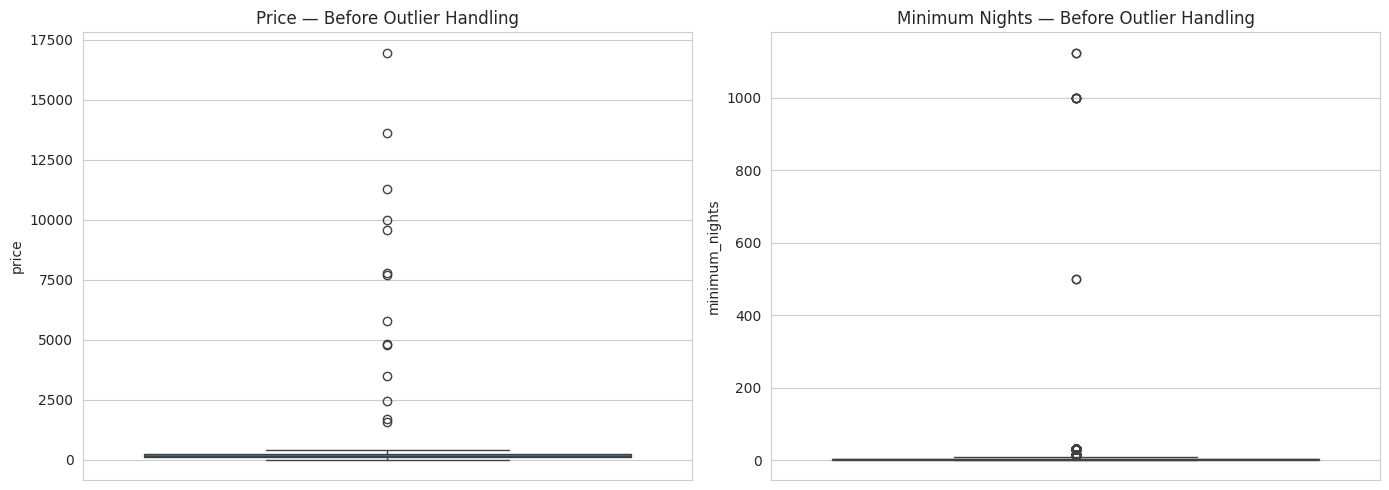

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df["price"], ax=axes[0], color="#2E86AB")
axes[0].set_title("Price — Before Outlier Handling")
sns.boxplot(y=df["minimum_nights"], ax=axes[1], color="#A23B72")
axes[1].set_title("Minimum Nights — Before Outlier Handling")
plt.tight_layout()
plt.savefig("charts/outliers_before.png", dpi=120)
plt.show()

In [17]:
# Invalid geocoordinates (0, 0) — clear data errors, not real NYC locations
invalid_geo = (df["latitude"] == 0) & (df["longitude"] == 0)
print("Rows with invalid (0,0) coordinates:", invalid_geo.sum())

# Zero or negative prices — invalid for a real listing
invalid_price = df["price"] <= 0
print("Rows with price <= 0:", invalid_price.sum())

# Unrealistic minimum_nights (NYC short-term rental law caps long-term at 365)
invalid_min_nights = df["minimum_nights"] > 365
print("Rows with minimum_nights > 365:", invalid_min_nights.sum())

Rows with invalid (0,0) coordinates: 8
Rows with price <= 0: 25
Rows with minimum_nights > 365: 10


In [18]:
# Remove rows with invalid coordinates or non-positive price (small number, safe to drop)
before = len(df)
df = df[~invalid_geo & ~invalid_price].reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with invalid geo/price")

# Cap unrealistic minimum_nights at 365 (winsorize rather than drop)
capped = (df["minimum_nights"] > 365).sum()
df["minimum_nights"] = df["minimum_nights"].clip(upper=365)
print(f"Capped {capped} minimum_nights values at 365")

Dropped 33 rows with invalid geo/price
Capped 10 minimum_nights values at 365


In [19]:
# Use IQR method to identify extreme price outliers
Q1, Q3 = df["price"].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
print(f"Price IQR upper bound: {upper_bound:.2f}")

price_outliers = df[df["price"] > upper_bound]
print(f"Price outliers (> {upper_bound:.2f}): {len(price_outliers)} rows ({len(price_outliers)/len(df)*100:.2f}%)")
price_outliers[["id", "neighbourhood_group", "room_type", "price"]].sort_values("price", ascending=False).head(10)

Price IQR upper bound: 502.50
Price outliers (> 502.50): 14 rows (0.23%)


,id,neighbourhood_group,room_type,price
4503,1004527,Brooklyn,Entire Home/Apt,16967
3158,1003176,Queens,Entire Home/Apt,13600
2690,1002706,Manhattan,Entire Home/Apt,11304
5252,1005280,Brooklyn,Entire Home/Apt,9976
5717,1005747,Brooklyn,Entire Home/Apt,9570
3755,1003776,Manhattan,Entire Home/Apt,7766
2267,1002281,Brooklyn,Entire Home/Apt,7684
532,1000535,Manhattan,Entire Home/Apt,5775
3650,1003671,Brooklyn,Entire Home/Apt,4838
617,1000621,Manhattan,Private Room,4797


Rather than dropping these listings outright (some very high prices may be
genuine luxury listings), we cap extreme values at the 99th percentile.
This reduces the influence of a handful of extreme outliers on summary
statistics and visualizations while preserving all records.

In [20]:
p99 = df["price"].quantile(0.99)
n_capped = (df["price"] > p99).sum()
df["price"] = df["price"].clip(upper=p99)
print(f"Capped {n_capped} price values at the 99th percentile (${p99:.2f})")

Capped 57 price values at the 99th percentile ($395.00)


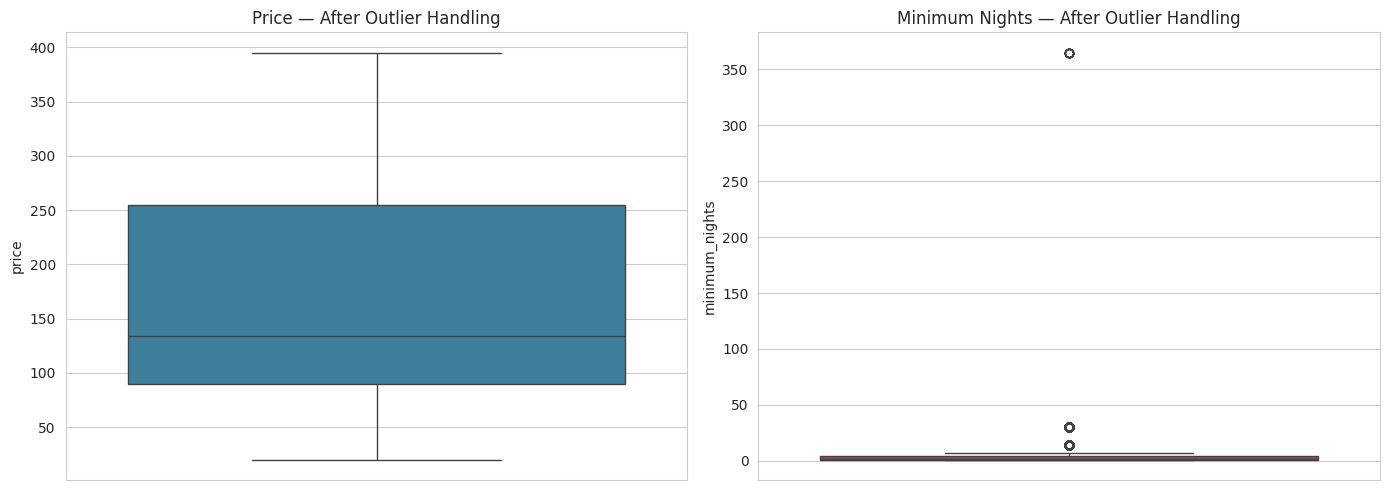

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df["price"], ax=axes[0], color="#2E86AB")
axes[0].set_title("Price — After Outlier Handling")
sns.boxplot(y=df["minimum_nights"], ax=axes[1], color="#A23B72")
axes[1].set_title("Minimum Nights — After Outlier Handling")
plt.tight_layout()
plt.savefig("charts/outliers_after.png", dpi=120)
plt.show()

## Final Cleaned Dataset Summary

In [22]:
print("Final shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nDtypes:")
print(df.dtypes)
df.head()

Final shape: (5967, 16)

Missing values:
id                                  0
name                                0
host_id                             0
host_name                           0
neighbourhood_group                 0
neighbourhood                       0
latitude                            0
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                       480
reviews_per_month                   0
calculated_host_listings_count      0
availability_365                    0
dtype: int64

Dtypes:
id                                         int64
name                                         str
host_id                                    int64
host_name                                    str
neighbourhood_group                          str
neighbourhood                                str
latitude                           

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1000000,Spacious entire home near Chelsea subway,18635,Wei G.,Manhattan,Chelsea,40.76759,-73.98548,Entire Home/Apt,139,1,9,2023-08-20,0.34,4,33
1,1000001,Cozy shared room in Chelsea,31488,Patricia C.,Manhattan,Chelsea,40.76816,-73.95948,Shared Room,23,1,7,2022-10-15,0.33,1,123
2,1000002,Cozy entire home in Bedford-Stuyvesant,21885,Jennifer F.,Brooklyn,Bedford-Stuyvesant,40.69268,-73.92529,Entire Home/Apt,327,5,0,NaT,0.00,1,45
3,1000003,Upper West Side private room with great views,38729,Robert G.,Manhattan,Upper West Side,40.79211,-73.99189,Private Room,132,2,6,2024-11-21,0.51,4,173
4,1000004,Sunny shared room close to everything - East Village,36657,William H.,Manhattan,East Village,40.77733,-73.95488,Shared Room,24,1,11,2023-02-12,1.15,2,211


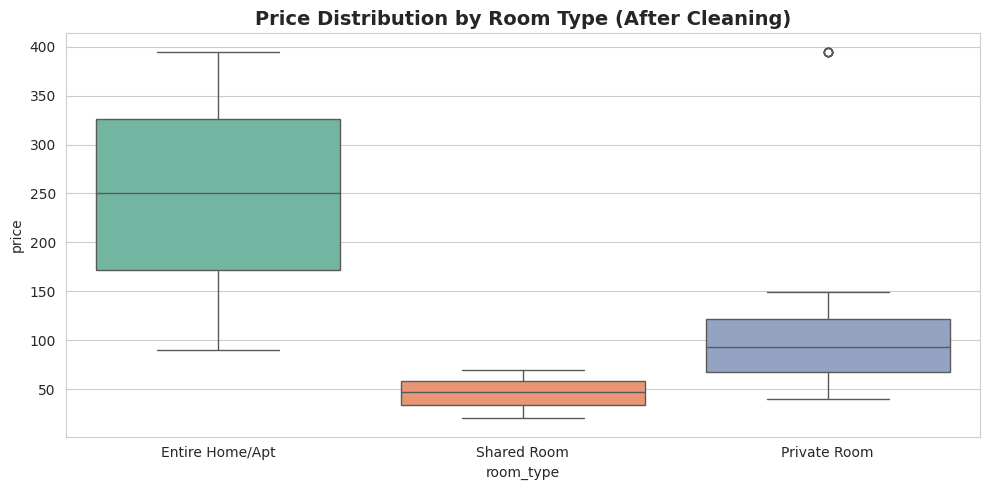

In [23]:
# Visualize cleaned data: price distribution by room type
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="room_type", y="price", hue="room_type", palette="Set2", legend=False)
plt.title("Price Distribution by Room Type (After Cleaning)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/price_by_room_type_clean.png", dpi=120)
plt.show()

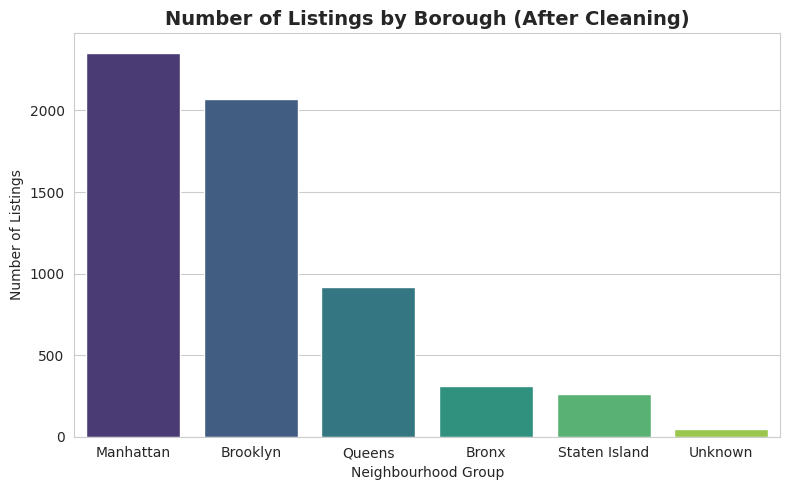

In [24]:
# Listings count by neighbourhood group
plt.figure(figsize=(8, 5))
group_counts = df["neighbourhood_group"].value_counts()
sns.barplot(x=group_counts.index, y=group_counts.values, hue=group_counts.index,
            palette="viridis", legend=False)
plt.title("Number of Listings by Borough (After Cleaning)", fontsize=14, fontweight="bold")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.savefig("charts/listings_by_borough_clean.png", dpi=120)
plt.show()

In [25]:
# Save the cleaned dataset
df.to_csv("data/nyc_airbnb_data_cleaned.csv", index=False)
print("Cleaned dataset saved to data/nyc_airbnb_data_cleaned.csv")

Cleaned dataset saved to data/nyc_airbnb_data_cleaned.csv


## Summary of Cleaning Steps

| Step | Issue | Action Taken |
|---|---|---|
| Missing data | `name`, `host_name` missing | Filled with `"No title"` / `"Unknown"` |
| Missing data | `neighbourhood_group` missing | Filled with `"Unknown"` |
| Missing data | `last_review`, `reviews_per_month` missing | Confirmed corresponds to 0 reviews; filled `reviews_per_month` with 0, left `last_review` as NaT (never reviewed) |
| Duplicates | Duplicate `id` rows | Dropped duplicates, keeping first occurrence |
| Standardization | Inconsistent casing in `neighbourhood_group`, `room_type` | Converted to Title Case |
| Standardization | Stray whitespace in `neighbourhood` | Stripped whitespace |
| Standardization | Numeric columns stored inconsistently | Coerced to numeric dtypes |
| Outliers | `price <= 0` | Dropped (invalid listings) |
| Outliers | `latitude`/`longitude` == (0, 0) | Dropped (invalid geocoding) |
| Outliers | `minimum_nights` > 365 | Capped at 365 |
| Outliers | Extreme `price` values | Capped at 99th percentile |

### Key Takeaways
- **Missingness can be informative.** The missing `last_review` and
  `reviews_per_month` values weren't random — they directly corresponded to
  listings with zero reviews, which guided the imputation strategy.
- **Duplicates aren't always exact-row duplicates.** Checking uniqueness of
  the primary key (`id`) caught duplicates that a naive `drop_duplicates()`
  on the full row might have handled differently depending on column order.
- **Standardization prevents silent analysis errors.** Without normalizing
  casing, a `groupby("neighbourhood_group")` would have treated `"Manhattan"`
  and `"MANHATTAN"` as different categories, skewing aggregate results.
- **Outlier handling is a judgment call.** Capping (winsorizing) was chosen
  over dropping for `price`, preserving the row count while limiting the
  influence of extreme values — appropriate when outliers may represent real
  but rare luxury listings rather than pure errors.